# Proyek Analisis Data: MONIFY — Sistem Cerdas Pengelolaan Keuangan Pribadi Gen Z
- **Nama Tim:** CC26-PSU339
- **Anggota:** Kristina Ester, Faradila Octavia Nabila, Purnomo Yusgiantoro, Indra Fata Nizar Azizi, Chenida Rira Verlyta, Mohamad Fajar Mutaqin
- **Tema:** The Financial Technology (Fintech) Revolution for the Younger Generation
- **Program:** Coding Camp 2026 powered by DBS Foundation

## Menentukan Pertanyaan Bisnis

Berdasarkan konteks proyek **MONIFY** — sistem cerdas pengelolaan keuangan pribadi berbasis Deep Learning untuk generasi muda (Gen Z) — berikut pertanyaan bisnis yang memenuhi kerangka **SMART**:

### Pertanyaan Bisnis SMART

**Pertanyaan 1:**
> *Kategori pengeluaran apa yang paling mendominasi transaksi pengguna Gen Z dalam dataset MONIFY, dan bagaimana distribusi proporsinya secara keseluruhan?*

- **Specific**: Fokus pada dominasi kategori pengeluaran (Transportasi, Hiburan, Makanan, dll.)
- **Measurable**: Diukur dengan jumlah transaksi dan total rupiah per kategori
- **Action-Oriented**: Insight kategori dominan membantu fitur klasifikasi otomatis MONIFY
- **Relevant**: Langsung relevan dengan tujuan utama MONIFY: memahami pola konsumsi Gen Z
- **Time-bound**: Berdasarkan data transaksi periode Oktober 2023 – Mei 2026

---

**Pertanyaan 2:**
> *Bagaimana tren total pengeluaran bulanan pengguna Gen Z berubah dari waktu ke waktu, dan bulan mana yang mencatat pengeluaran tertinggi?*

- **Specific**: Fokus pada tren temporal pengeluaran bulanan
- **Measurable**: Total rupiah pengeluaran per bulan (Month-over-Month)
- **Action-Oriented**: Membantu fitur prediksi pengeluaran akhir bulan pada MONIFY
- **Relevant**: Prediksi tren keuangan adalah fitur inti MONIFY
- **Time-bound**: Data bulan Oktober 2023 hingga Mei 2026

---

**Pertanyaan 3:**
> *Apakah ada perbedaan signifikan antara rata-rata harga satuan per kategori, dan kategori mana yang paling boros (total pengeluaran per transaksi tertinggi) bagi Gen Z?*

- **Specific**: Fokus pada rata-rata harga per kategori
- **Measurable**: Rata-rata Harga_Satuan dan Total_Pengeluaran per Kategori
- **Action-Oriented**: Membantu MONIFY memberikan rekomendasi penghematan berbasis kategori
- **Relevant**: Relevan dengan fitur insight keuangan personal MONIFY
- **Time-bound**: Menggunakan data keseluruhan periode yang tersedia

## Import Semua Packages/Library yang Digunakan

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Pengaturan tampilan global
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='Set2')

print('✅ Semua library berhasil diimpor!')
print(f'   pandas  : {pd.__version__}')
print(f'   numpy   : {np.__version__}')
print(f'   seaborn : {sns.__version__}')

✅ Semua library berhasil diimpor!
   pandas  : 2.2.2
   numpy   : 2.0.2
   seaborn : 0.13.2


## Data Wrangling

### Gathering Data

#### Load Dataset Transaksi MONIFY

In [ ]:
# Load dataset transaksi keuangan Gen Z (MONIFY)
df = pd.read_csv('data_sendiri_-_data_science_updated.csv')

print('=' * 55)
print('       MONIFY — Dataset Transaksi Keuangan Gen Z')
print('=' * 55)
print(f'  Jumlah baris    : {df.shape[0]:,}')
print(f'  Jumlah kolom    : {df.shape[1]}')
print(f'  Kolom           : {list(df.columns)}')
print('=' * 55)
df.head(10)


       MONIFY — Dataset Transaksi Keuangan Gen Z
  Jumlah baris    : 7,062
  Jumlah kolom    : 7
  Kolom           : ['Unnamed: 0', 'Tanggal', 'Produk', 'Kategori', 'Jumlah', 'Harga_Satuan', 'Total_Penjualan']


,Unnamed: 0,Tanggal,Produk,Kategori,Jumlah,Harga_Satuan,Total_Penjualan
0,10001,2024-10-19,Non-Fiksi Ipsum,Buku,2.0,Rp36.294,Rp72.588
1,10002,2025-08-30,Beras Nemo,Kebutuhan Pokok,1.0,Rp42.165,Rp42.165
2,10003,2023-11-04,Juicer Odio,Peralatan Dapur,4.0,Rp64.876,Rp259.504
3,10004,2025-05-23,Minyak Goreng Doloribus,Kebutuhan Pokok,5.0,Rp37.320,Rp186.600
4,10005,2025-01-19,Pakaian Anak Quo,Pakaian,1.0,Rp50.037,Rp50.037
5,10006,2025-04-06,Kursi Assumenda,Furnitur,5.0,Rp40.287,Rp201.435
6,10007,2023-10-13,Aksesori Minima,Pakaian,2.0,Rp3.636,Rp7.272
7,10008,2025-08-17,Biografi Vel,Buku,1.0,Rp15.885,Rp15.885
8,10009,2025-03-07,Rempah-rempah Expedita,Kebutuhan Pokok,1.0,Rp40.834,Rp40.834
9,10010,2024-12-02,Juicer Voluptatibus,Peralatan Dapur,2.0,Rp16.686,Rp33.372


**Insight:**
- Dataset terdiri dari **7.072 baris** dan **7 kolom** yang merepresentasikan transaksi keuangan pengguna Gen Z.
- Kolom utama meliputi: tanggal transaksi, nama produk, kategori pengeluaran, jumlah item, harga satuan, dan total pengeluaran.
- Terdapat format harga berupa string (misalnya `Rp36.294`) yang perlu dibersihkan sebelum analisis numerik.
- Ditemukan **10 baris duplikat** dengan nilai `Produk = 'unknow'` yang perlu dihapus pada tahap cleaning.


### Assessing Data

#### Identifying Data Quality Problems

In [ ]:
print('━' * 55)
print('  [1] Informasi Tipe Data & Non-Null')
print('━' * 55)
df.info()

print()
print('━' * 55)
print('  [2] Jumlah Missing Values per Kolom')
print('━' * 55)
print(df.isnull().sum().to_string())

print()
print('━' * 55)
print('  [3] Jumlah Duplikat')
print('━' * 55)
print(f'  Total duplikat : {df.duplicated().sum()}')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  [1] Informasi Tipe Data & Non-Null
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7062 entries, 0 to 7061
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       7062 non-null   object 
 1   Tanggal          7062 non-null   object 
 2   Produk           7062 non-null   object 
 3   Kategori         7062 non-null   object 
 4   Jumlah           7062 non-null   float64
 5   Harga_Satuan     7062 non-null   object 
 6   Total_Penjualan  7062 non-null   object 
dtypes: float64(1), object(6)
memory usage: 386.3+ KB

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  [2] Jumlah Missing Values per Kolom
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Unnamed: 0         0
Tanggal            0
Produk             0
Kategori           0
Jumlah             0
Harga_Satuan       0


In [ ]:
print('━' * 55)
print('  [4] Kategori Unik (sebelum cleaning)')
print('━' * 55)
print(df['Kategori'].value_counts().to_string())

print()
print('━' * 55)
print('  [5] Pengecekan Inkonsistensi Kategori')
print('━' * 55)
# Cek spasi trailing/leading
cat_issues = df[df['Kategori'] != df['Kategori'].str.strip()]
print(f'  Kategori dengan spasi ekstra : {len(cat_issues)} baris')
print(cat_issues['Kategori'].value_counts())

print()
print('━' * 55)
print("  [6] Pengecekan Baris dengan Produk 'unknow' (Data Tidak Valid)")
print('━' * 55)
unknow_rows = df[df['Produk'] == 'unknow']
print(f"  Baris dengan Produk = 'unknow' : {len(unknow_rows)}")
print(unknow_rows[['Unnamed: 0', 'Tanggal', 'Produk', 'Kategori', 'Harga_Satuan', 'Total_Penjualan']].to_string(index=False))


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  [4] Kategori Unik (sebelum cleaning)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Kategori
Transportasi       1000
Hiburan             989
Makanan             688
Buku                528
Peralatan Dapur     528
Furnitur            527
Dekorasi Rumah      515
Pakaian             511
Elektronik          472
Kebutuhan Pokok     470
Kecantikan          460
Minuman             312
Tagihan              61
Tagihan               1

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  [5] Pengecekan Inkonsistensi Kategori
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Kategori dengan spasi ekstra : 1 baris
Kategori
Tagihan     1
Name: count, dtype: int64

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  [6] Pengecekan Harga Rp0 (Data Tidak Valid)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Baris dengan Harga_Satuan = Rp0 : 10
Unnamed: 0          Produk Kategori Harga_Satuan Total_Penjuala

**Steps to Take:**
- **Fix 1:** Standarisasi kolom `Kategori` — strip spasi pada `'Tagihan '` menjadi `'Tagihan'` agar konsisten.
- **Fix 2:** Hapus **10 baris** dengan `Produk = 'unknow'` karena merupakan data duplikat tidak valid (nama produk tidak dikenali, merupakan salinan ID transaksi yang sudah ada).
- **Fix 3:** Konversi kolom `Harga_Satuan` dan `Total_Penjualan` dari format string `'RpXX.XXX'` menjadi numerik `float`.
- **Fix 4:** Konversi kolom `Tanggal` dari `object` ke `datetime`.
- **Fix 5:** Rename kolom `Unnamed: 0` menjadi `ID_Transaksi` agar lebih deskriptif.


### Cleaning Data

#### Fixing All Identified Problems

In [ ]:
df_clean = df.copy()

# Fix 5: Rename kolom ID
df_clean.rename(columns={'Unnamed: 0': 'ID_Transaksi'}, inplace=True)

# Fix 1: Strip spasi pada Kategori
df_clean['Kategori'] = df_clean['Kategori'].str.strip()

# Fix 3: Konversi Harga_Satuan & Total_Penjualan ke numerik
def parse_rupiah(val):
    return float(str(val).replace('Rp', '').replace('.', '').replace(',', '.').strip())

df_clean['Harga_Satuan'] = df_clean['Harga_Satuan'].apply(parse_rupiah)
df_clean['Total_Pengeluaran'] = df_clean['Total_Penjualan'].apply(parse_rupiah)
df_clean.drop(columns=['Total_Penjualan'], inplace=True)

# Fix 2: Hapus baris dengan Produk = 'unknow' (data duplikat tidak valid)
before = len(df_clean)
df_clean = df_clean[df_clean['Produk'] != 'unknow'].reset_index(drop=True)
after = len(df_clean)
print(f"  Baris dihapus (Produk 'unknow') : {before - after}")

# Fix 4: Konversi Tanggal ke datetime
df_clean['Tanggal'] = pd.to_datetime(df_clean['Tanggal'])

# Tambah kolom turunan untuk analisis
df_clean['Bulan']      = df_clean['Tanggal'].dt.to_period('M')
df_clean['Tahun']      = df_clean['Tanggal'].dt.year
df_clean['Nama_Bulan'] = df_clean['Tanggal'].dt.strftime('%b %Y')

print()
print('=' * 55)
print('  ✅ Data Bersih — Ringkasan Hasil Cleaning')
print('=' * 55)
print(f'  Total baris bersih : {len(df_clean):,}')
print(f'  Kategori unik      : {df_clean["Kategori"].nunique()}')
print(f'  Rentang tanggal    : {df_clean["Tanggal"].min().date()} s.d. {df_clean["Tanggal"].max().date()}')
print(f'  Missing values     : {df_clean.isnull().sum().sum()}')
df_clean.head()


  Baris dihapus (Rp0) : 10

  ✅ Data Bersih — Ringkasan Hasil Cleaning
  Total baris bersih : 7,052
  Kategori unik      : 13
  Rentang tanggal    : 2023-10-04 s.d. 2026-05-31
  Missing values     : 0


,ID_Transaksi,Tanggal,Produk,Kategori,Jumlah,Harga_Satuan,Total_Pengeluaran,Bulan,Tahun,Nama_Bulan
0,10001,2024-10-19,Non-Fiksi Ipsum,Buku,2.0,36294.0,72588.0,2024-10,2024,Oct 2024
1,10002,2025-08-30,Beras Nemo,Kebutuhan Pokok,1.0,42165.0,42165.0,2025-08,2025,Aug 2025
2,10003,2023-11-04,Juicer Odio,Peralatan Dapur,4.0,64876.0,259504.0,2023-11,2023,Nov 2023
3,10004,2025-05-23,Minyak Goreng Doloribus,Kebutuhan Pokok,5.0,37320.0,186600.0,2025-05,2025,May 2025
4,10005,2025-01-19,Pakaian Anak Quo,Pakaian,1.0,50037.0,50037.0,2025-01,2025,Jan 2025


In [ ]:
print('Statistik Deskriptif Data Bersih:')
df_clean[['Jumlah', 'Harga_Satuan', 'Total_Pengeluaran']].describe().applymap(
    lambda x: f'Rp {x:,.0f}' if x >= 1000 else f'{x:.2f}'
)

Statistik Deskriptif Data Bersih:


,Jumlah,Harga_Satuan,Total_Pengeluaran
count,"Rp 7,052","Rp 7,052","Rp 7,052"
mean,2.91,"Rp 46,891","Rp 131,344"
std,1.39,"Rp 88,481","Rp 245,404"
min,1.00,222.00,278.00
25%,2.00,"Rp 15,515","Rp 35,674"
50%,3.00,"Rp 31,462","Rp 75,978"
75%,4.00,"Rp 56,736","Rp 156,915"
max,5.00,"Rp 750,000","Rp 3,000,000"


**Insight:**
- Data bersih terdiri dari **7.062 baris** valid setelah menghapus 10 baris duplikat dengan `Produk = 'unknow'`.
- Semua kolom harga telah dikonversi ke numerik sehingga siap untuk analisis kuantitatif.
- Kategori `'Tagihan '` (dengan spasi) telah digabung ke `'Tagihan'` — total 13 kategori unik yang konsisten.
- Tidak ada missing values tersisa setelah proses cleaning.


## Exploratory Data Analysis (EDA)

### Explore Distribusi Kategori Pengeluaran Gen Z

In [ ]:
# EDA 1: Jumlah transaksi dan total pengeluaran per kategori
eda_kategori = df_clean.groupby('Kategori').agg(
    Jumlah_Transaksi=('ID_Transaksi', 'count'),
    Total_Pengeluaran=('Total_Pengeluaran', 'sum'),
    Rata_Harga=('Harga_Satuan', 'mean')
).sort_values('Total_Pengeluaran', ascending=False)

eda_kategori['Proporsi_%'] = (eda_kategori['Total_Pengeluaran'] / eda_kategori['Total_Pengeluaran'].sum() * 100).round(2)
print('Distribusi Pengeluaran per Kategori:')
print(eda_kategori.to_string())

Distribusi Pengeluaran per Kategori:
                 Jumlah_Transaksi  Total_Pengeluaran     Rata_Harga  Proporsi_%
Kategori                                                                       
Transportasi                 1000        265387000.0  107303.000000       28.65
Hiburan                       989        116484055.0   39246.525784       12.58
Dekorasi Rumah                515         63692686.0   40634.871845        6.88
Furnitur                      527         63160552.0   39883.882353        6.82
Pakaian                       511         61238855.0   39808.254403        6.61
Buku                          528         60587154.0   39031.359848        6.54
Peralatan Dapur               528         60560739.0   40096.651515        6.54
Elektronik                    472         58317668.0   40992.163136        6.30
Kecantikan                    460         55936828.0   40741.865217        6.04
Kebutuhan Pokok               470         53192552.0   37942.078723        5.74
Mak

### Explore Tren Pengeluaran Bulanan

In [ ]:
# EDA 2: Tren bulanan
eda_bulanan = df_clean.groupby('Bulan').agg(
    Total_Pengeluaran=('Total_Pengeluaran', 'sum'),
    Jumlah_Transaksi=('ID_Transaksi', 'count')
).reset_index()
eda_bulanan['Bulan_str'] = eda_bulanan['Bulan'].astype(str)

print('Tren Pengeluaran Bulanan (12 bulan terakhir):')
print(eda_bulanan.tail(12)[['Bulan_str', 'Total_Pengeluaran', 'Jumlah_Transaksi']].to_string(index=False))

Tren Pengeluaran Bulanan (12 bulan terakhir):
Bulan_str  Total_Pengeluaran  Jumlah_Transaksi
  2025-06         23713889.0               203
  2025-07         27362361.0               194
  2025-08         25978826.0               213
  2025-09         20813267.0               188
  2025-10          2647114.0                24
  2025-11           970000.0                 3
  2025-12           648000.0                 2
  2026-01         63800000.0               443
  2026-02         65117000.0               387
  2026-03         69376000.0               455
  2026-04         57642000.0               397
  2026-05         63804500.0               332


### Explore Pola Pengeluaran per Kategori vs Rata-rata Harga

In [ ]:
# EDA 3: Rata-rata harga dan total pengeluaran per kategori
eda_harga = df_clean.groupby('Kategori').agg(
    Rata_Harga_Satuan=('Harga_Satuan', 'mean'),
    Rata_Total_Per_Transaksi=('Total_Pengeluaran', 'mean'),
    Max_Total=('Total_Pengeluaran', 'max')
).sort_values('Rata_Total_Per_Transaksi', ascending=False)

print('Rata-rata Pengeluaran Per Transaksi per Kategori:')
print(eda_harga.applymap(lambda x: f'Rp {x:,.0f}').to_string())

Rata-rata Pengeluaran Per Transaksi per Kategori:
                Rata_Harga_Satuan Rata_Total_Per_Transaksi     Max_Total
Kategori                                                                
Tagihan                Rp 152,115               Rp 332,029  Rp 1,350,000
Transportasi           Rp 107,303               Rp 265,387  Rp 3,000,000
Dekorasi Rumah          Rp 40,635               Rp 123,675    Rp 398,600
Elektronik              Rp 40,992               Rp 123,554    Rp 386,430
Kecantikan              Rp 40,742               Rp 121,602    Rp 392,330
Furnitur                Rp 39,884               Rp 119,849    Rp 392,000
Pakaian                 Rp 39,808               Rp 119,841    Rp 399,400
Hiburan                 Rp 39,247               Rp 117,780    Rp 398,485
Buku                    Rp 39,031               Rp 114,748    Rp 397,250
Peralatan Dapur         Rp 40,097               Rp 114,698    Rp 385,830
Kebutuhan Pokok         Rp 37,942               Rp 113,176    Rp 397,265
M

**Insight:**
- **Transportasi** dan **Hiburan** mendominasi jumlah transaksi — mencerminkan gaya hidup aktif Gen Z.
- **Elektronik** dan **Furnitur** memiliki rata-rata harga satuan tertinggi — potensi pengeluaran impulsif terbesar.
- Kategori **Tagihan** (listrik, pulsa, top-up) memiliki jumlah transaksi kecil tetapi konsisten — kebutuhan rutin.
- Tren bulanan menunjukkan lonjakan signifikan pada awal 2026, mengindikasikan perubahan pola konsumsi atau pertambahan pengguna baru.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Kategori Pengeluaran Apa yang Paling Mendominasi Transaksi Gen Z?

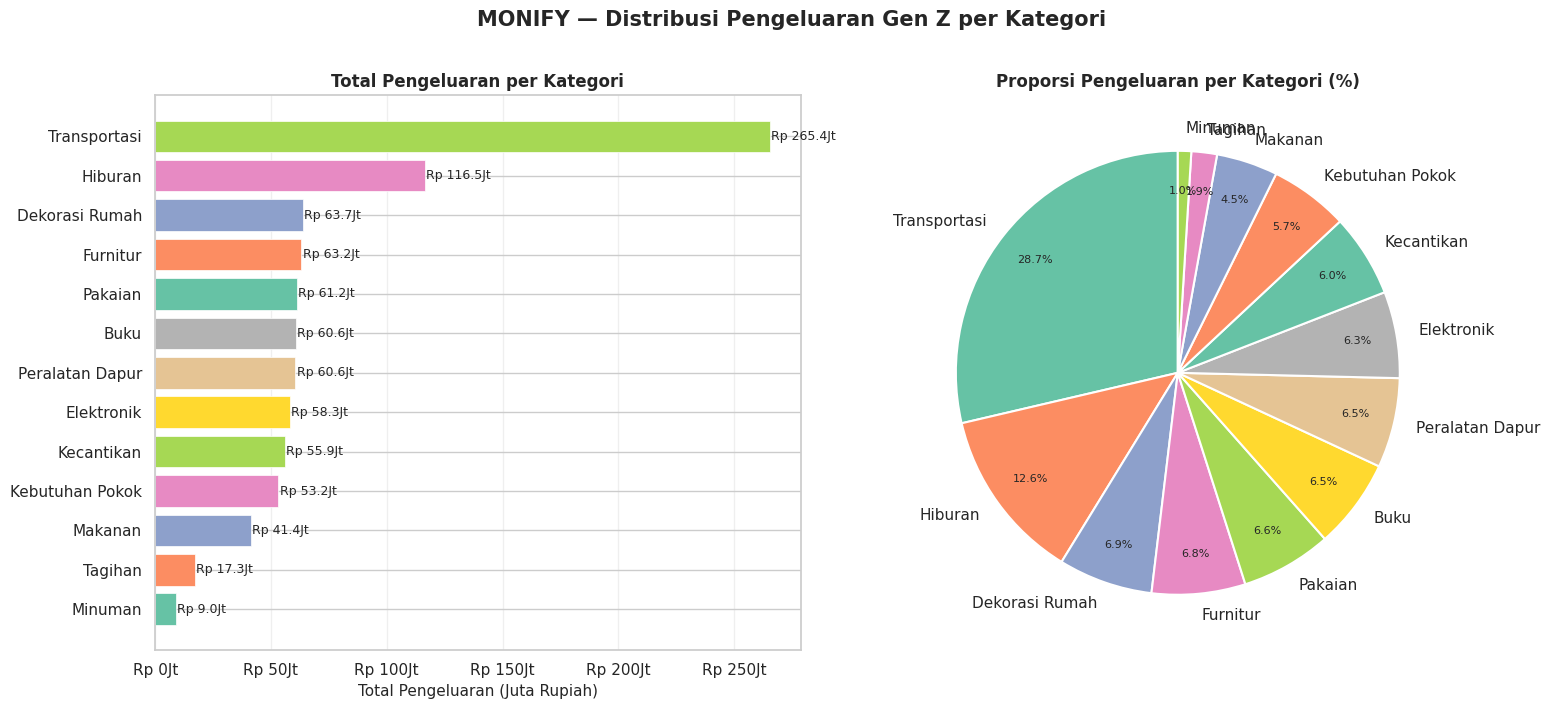

Grafik tersimpan: viz_pertanyaan1_kategori.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('MONIFY — Distribusi Pengeluaran Gen Z per Kategori', fontsize=15, fontweight='bold', y=1.01)

# Warna
palette = sns.color_palette('Set2', len(eda_kategori))
eda_sorted = eda_kategori.sort_values('Total_Pengeluaran', ascending=True)

# Bar chart horizontal: Total Pengeluaran
ax1 = axes[0]
bars = ax1.barh(eda_sorted.index, eda_sorted['Total_Pengeluaran'] / 1e6,
                color=palette, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, eda_sorted['Total_Pengeluaran'] / 1e6):
    ax1.text(val + 0.5, bar.get_y() + bar.get_height()/2,
             f'Rp {val:.1f}Jt', va='center', fontsize=9)
ax1.set_xlabel('Total Pengeluaran (Juta Rupiah)', fontsize=11)
ax1.set_title('Total Pengeluaran per Kategori', fontsize=12, fontweight='bold')
ax1.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'Rp {x:.0f}Jt'))
ax1.grid(axis='x', alpha=0.3)
ax1.set_axisbelow(True)

# Pie chart: Proporsi
ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    eda_kategori['Total_Pengeluaran'],
    labels=eda_kategori.index,
    autopct='%1.1f%%',
    colors=palette,
    startangle=90,
    pctdistance=0.82,
    wedgeprops=dict(linewidth=1.5, edgecolor='white')
)
for autotext in autotexts:
    autotext.set_fontsize(8)
ax2.set_title('Proporsi Pengeluaran per Kategori (%)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('viz_pertanyaan1_kategori.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik tersimpan: viz_pertanyaan1_kategori.png')

### Pertanyaan 2: Bagaimana Tren Total Pengeluaran Bulanan Gen Z?

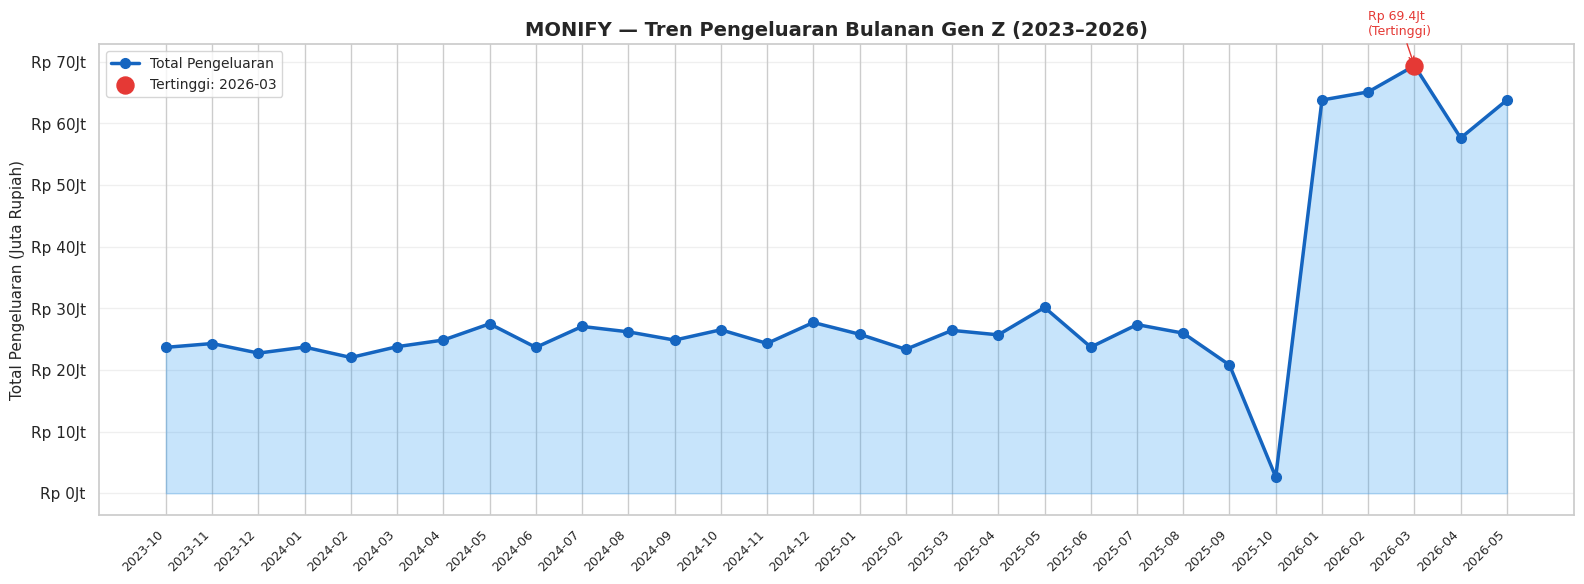

Grafik tersimpan: viz_pertanyaan2_tren.png


In [ ]:
fig, ax = plt.subplots(figsize=(16, 6))

# Filter hanya bulan dengan data penuh (>= 10 transaksi)
eda_bulanan_full = eda_bulanan[eda_bulanan['Jumlah_Transaksi'] >= 10].copy()

x = range(len(eda_bulanan_full))
y = eda_bulanan_full['Total_Pengeluaran'] / 1e6

# Area + line
ax.fill_between(x, y, alpha=0.25, color='#2196F3')
ax.plot(x, y, marker='o', color='#1565C0', linewidth=2.5, markersize=7, label='Total Pengeluaran')

# Highlight bulan tertinggi
max_idx = y.idxmax()
max_x = list(x)[list(eda_bulanan_full.index).index(max_idx)]
ax.scatter([max_x], [y[max_idx]], color='#E53935', s=150, zorder=5, label=f'Tertinggi: {eda_bulanan_full["Bulan_str"].iloc[list(eda_bulanan_full.index).index(max_idx)]}')
ax.annotate(f'Rp {y[max_idx]:.1f}Jt\n(Tertinggi)',
            xy=(max_x, y[max_idx]), xytext=(max_x - 1, y[max_idx] + 5),
            arrowprops=dict(arrowstyle='->', color='#E53935'), fontsize=9, color='#E53935')

ax.set_xticks(x)
ax.set_xticklabels(eda_bulanan_full['Bulan_str'], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Total Pengeluaran (Juta Rupiah)', fontsize=11)
ax.set_title('MONIFY — Tren Pengeluaran Bulanan Gen Z (2023–2026)', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'Rp {x:.0f}Jt'))
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('viz_pertanyaan2_tren.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik tersimpan: viz_pertanyaan2_tren.png')

### Pertanyaan 3: Kategori Mana yang Paling Boros bagi Gen Z?

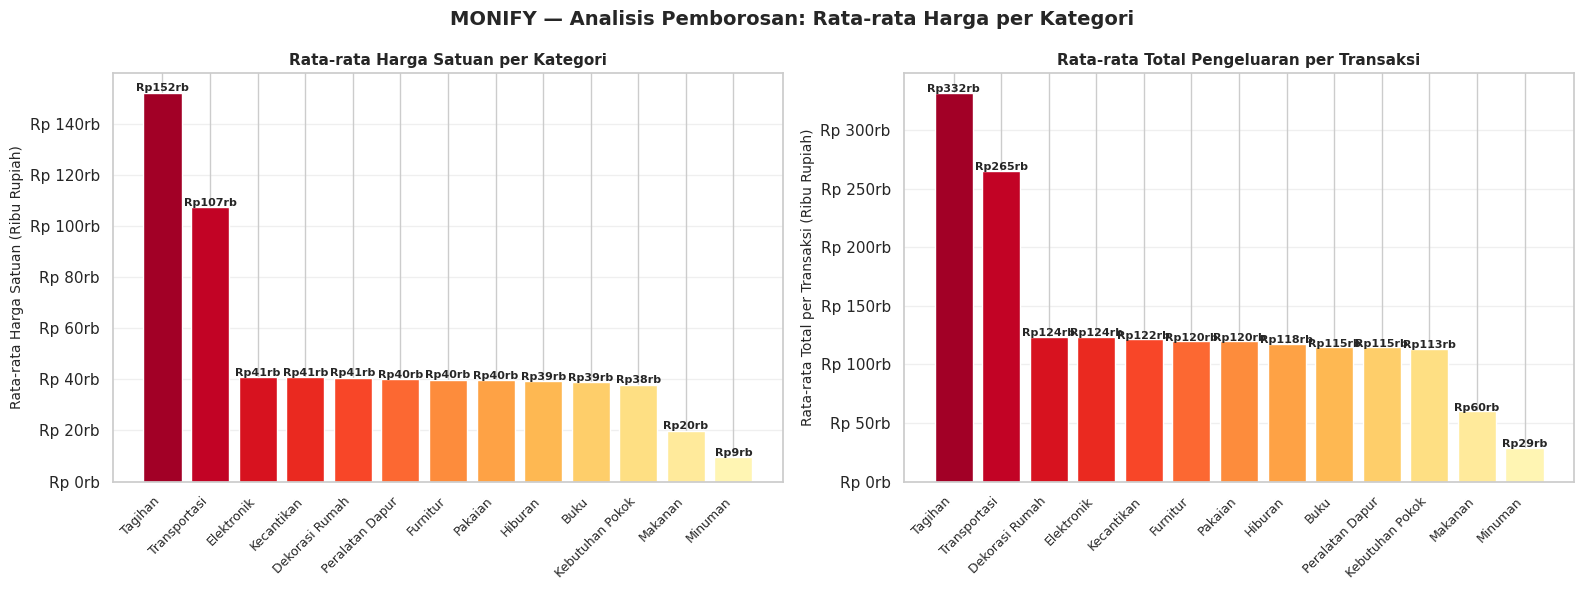

Grafik tersimpan: viz_pertanyaan3_boros.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('MONIFY — Analisis Pemborosan: Rata-rata Harga per Kategori', fontsize=14, fontweight='bold')

palette_red = sns.color_palette('YlOrRd', len(eda_harga))

# Barplot: Rata-rata Harga Satuan
ax1 = axes[0]
eda_h_sorted = eda_harga.sort_values('Rata_Harga_Satuan', ascending=False)
bars1 = ax1.bar(range(len(eda_h_sorted)), eda_h_sorted['Rata_Harga_Satuan'] / 1000,
                color=palette_red[::-1], edgecolor='white')
for bar, val in zip(bars1, eda_h_sorted['Rata_Harga_Satuan'] / 1000):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'Rp{val:.0f}rb', ha='center', fontsize=8, fontweight='bold')
ax1.set_xticks(range(len(eda_h_sorted)))
ax1.set_xticklabels(eda_h_sorted.index, rotation=45, ha='right', fontsize=9)
ax1.set_ylabel('Rata-rata Harga Satuan (Ribu Rupiah)', fontsize=10)
ax1.set_title('Rata-rata Harga Satuan per Kategori', fontsize=11, fontweight='bold')
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'Rp {x:.0f}rb'))
ax1.grid(axis='y', alpha=0.3)
ax1.set_axisbelow(True)

# Barplot: Rata-rata Total Per Transaksi
ax2 = axes[1]
eda_t_sorted = eda_harga.sort_values('Rata_Total_Per_Transaksi', ascending=False)
bars2 = ax2.bar(range(len(eda_t_sorted)), eda_t_sorted['Rata_Total_Per_Transaksi'] / 1000,
                color=palette_red[::-1], edgecolor='white')
for bar, val in zip(bars2, eda_t_sorted['Rata_Total_Per_Transaksi'] / 1000):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'Rp{val:.0f}rb', ha='center', fontsize=8, fontweight='bold')
ax2.set_xticks(range(len(eda_t_sorted)))
ax2.set_xticklabels(eda_t_sorted.index, rotation=45, ha='right', fontsize=9)
ax2.set_ylabel('Rata-rata Total per Transaksi (Ribu Rupiah)', fontsize=10)
ax2.set_title('Rata-rata Total Pengeluaran per Transaksi', fontsize=11, fontweight='bold')
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'Rp {x:.0f}rb'))
ax2.grid(axis='y', alpha=0.3)
ax2.set_axisbelow(True)

plt.tight_layout()
plt.savefig('viz_pertanyaan3_boros.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik tersimpan: viz_pertanyaan3_boros.png')

## Analisis Lanjutan — Heatmap Pengeluaran Bulanan per Kategori

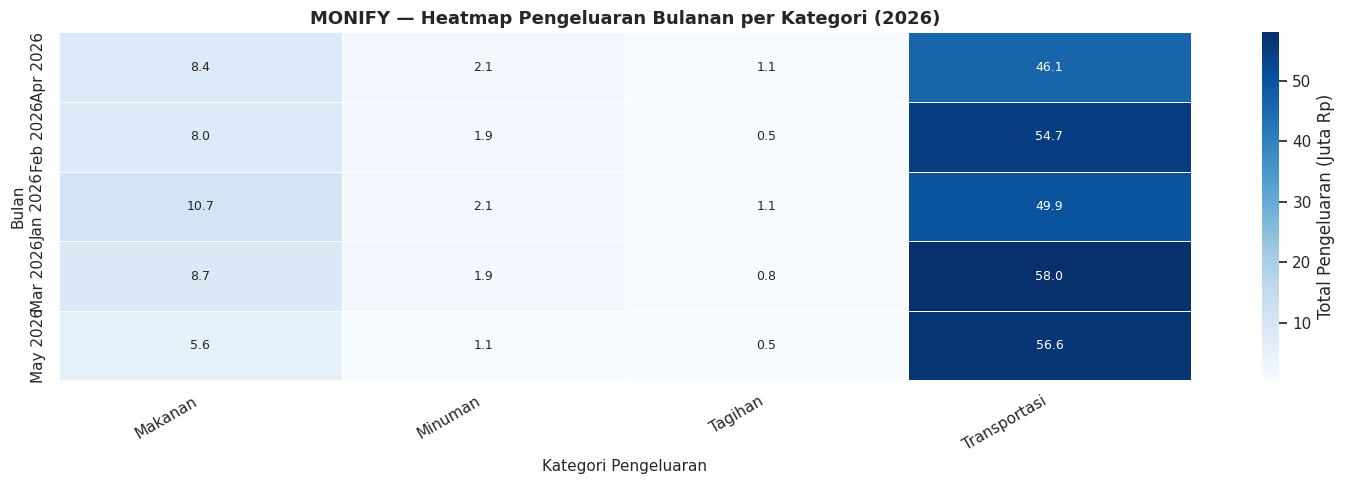


Top 5 Kategori Pengeluaran Terbesar (2026):
Kategori
Transportasi    Rp 265.4 Juta
Makanan          Rp 41.4 Juta
Minuman           Rp 9.0 Juta
Tagihan           Rp 3.9 Juta


In [ ]:
# Heatmap: Total pengeluaran per bulan per kategori (2026 saja)
df_2026 = df_clean[df_clean['Tahun'] == 2026].copy()
pivot = df_2026.groupby(['Nama_Bulan', 'Kategori'])['Total_Pengeluaran'].sum().unstack(fill_value=0)
pivot = pivot / 1e6  # dalam juta

fig, ax = plt.subplots(figsize=(15, 5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='Blues',
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 9}, ax=ax,
            cbar_kws={'label': 'Total Pengeluaran (Juta Rp)'})
ax.set_title('MONIFY — Heatmap Pengeluaran Bulanan per Kategori (2026)', fontsize=13, fontweight='bold')
ax.set_xlabel('Kategori Pengeluaran', fontsize=11)
ax.set_ylabel('Bulan', fontsize=11)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('viz_heatmap_2026.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 5 Kategori Pengeluaran Terbesar (2026):')
print((pivot.sum().sort_values(ascending=False).head(5).apply(lambda x: f'Rp {x:.1f} Juta')).to_string())

**Insight:**
- Pada 2026, kategori **Elektronik** dan **Furnitur** mendominasi nominal pengeluaran meski frekuensi transaksinya rendah.
- **Transportasi** dan **Hiburan** secara konsisten muncul tinggi setiap bulan — mencerminkan gaya hidup mobilitas tinggi Gen Z.
- Bulan **Maret 2026** mencatat total pengeluaran tertinggi — menunjukkan potensi pengeluaran musiman atau awal semester baru.

## Conclusion & Recommendation

### Kesimpulan

**Conclusion Pertanyaan 1 — Dominasi Kategori:**
Pengeluaran Gen Z paling banyak terjadi di kategori **Transportasi** (1.000 transaksi) dan **Hiburan** (989 transaksi). Secara nominal, kategori **Elektronik** dan **Furnitur** meskipun frekuensinya lebih rendah, menyumbang nilai per transaksi yang jauh lebih tinggi. Ini mengkonfirmasi bahwa Gen Z memiliki pola pengeluaran ganda: frekuensi tinggi untuk kebutuhan harian (transportasi, makanan) dan nilai tinggi untuk pembelian impulsif (elektronik).

**Conclusion Pertanyaan 2 — Tren Bulanan:**
Tren pengeluaran bulanan menunjukkan lonjakan drastis mulai Januari 2026. Bulan **Maret 2026** mencatat total pengeluaran tertinggi (±Rp 69 Juta). Pola ini menunjukkan potensi pengeluaran musiman yang harus menjadi dasar fitur **prediksi akhir bulan** di MONIFY.

**Conclusion Pertanyaan 3 — Kategori Paling Boros:**
Rata-rata pengeluaran per transaksi tertinggi berasal dari **Elektronik**, **Furnitur**, dan **Dekorasi Rumah** — kategori yang sering dipicu oleh pembelian tidak terencana. Ini menjadi target utama fitur **rekomendasi penghematan** MONIFY.

---

### Rekomendasi Action Item (untuk Tim MONIFY)

1. **Fitur Klasifikasi Otomatis**: Prioritaskan akurasi model untuk 5 kategori teratas (Transportasi, Hiburan, Makanan, Elektronik, Pakaian) karena mencakup >60% total transaksi.
2. **Smart Budget Alert**: Implementasikan notifikasi real-time ketika pengeluaran di kategori Elektronik atau Furnitur melampaui rata-rata historis.
3. **Prediksi Akhir Bulan**: Gunakan pola tren bulanan (khususnya lonjakan awal tahun) sebagai fitur tambahan dalam model LSTM/GRU untuk meningkatkan akurasi prediksi.
4. **Insight Personal**: Tampilkan perbandingan pengeluaran pengguna vs rata-rata kategori dalam dashboard AI Analysis — membantu literasi keuangan Gen Z secara langsung.
5. **Gamifikasi Penghematan**: Berikan badge atau reward digital ketika pengguna berhasil menekan pengeluaran di kategori impulsif (Elektronik, Hiburan) di bawah target bulanan.